In [1]:
import numpy as np
import pandas as pd
import mne
import mne_bids

bids_dir = '../../../'

subjects = [
    "40", "46", "05", "09", "12", "14",
    "16", "19", "20", "25", "37"
]

group_speech = []
group_music  = []
group_rest   = []
group_freqs  = []


In [2]:
import numpy as np
import pandas as pd
import mne
import mne_bids

session = "iemu"
acquisition = "clinical"
datatype = "ieeg"
target_fs = 512

# Containers
processed_subjects = []
group_speech = []
group_music = []
group_rest = []
group_freqs = []


def select_auditory_channels(channels_df, electrodes_df):
    """
    Select auditory cortex electrodes.
    Coordinate-based PRIMARY, name-based SECONDARY.
    """
    merged = channels_df.merge(
        electrodes_df,
        on="name",
        how="inner"
    )

    auditory = []

    for _, row in merged.iterrows():
        name = row["name"]
        x, y, z = row["x"], row["y"], row["z"]

        coord_match = (
            abs(x) >= 35 and
            -20 <= y <= 20 and
            -10 <= z <= 25
        )

        name_match = name.startswith((
            "HG", "H", "PT", "ST",
            "A", "IPR", "AHL", "AHR"
        ))

        if coord_match or (name_match and abs(x) >= 30):
            auditory.append(name)

    return auditory


for sub in subjects:
    try:
        print(f"\nProcessing sub-{sub} (auditory cortex)")
        bids_path = mne_bids.BIDSPath(
            subject=sub, session=session, datatype=datatype, root=bids_dir
        )

        channels_path = bids_path.copy().update(
            suffix="channels", extension="tsv"
        ).match()[0]
        channels = pd.read_csv(channels_path, sep="\t")

        type_map = channels.set_index("name")["type"].str.lower().to_dict()

        bads = channels.loc[
            (channels["type"].isin(["ECOG", "SEEG", "EEG"])) &
            (channels["status"] == "bad"),
            "name"
        ].tolist()

        electrodes_path = bids_path.copy().update(
            suffix="electrodes", extension="tsv"
        ).match()[0]
        electrodes = pd.read_csv(electrodes_path, sep="\t")

        auditory_chs = select_auditory_channels(channels, electrodes)

        if len(auditory_chs) == 0:
            print("  No auditory electrodes → skipping subject.")
            continue
        task_vhdr = bids_path.copy().update(
            task="film", acquisition=acquisition,
            suffix="ieeg", extension="vhdr"
        ).match()[0]

        raw = mne.io.read_raw_brainvision(
            task_vhdr, preload=True, verbose=False
        )

        raw.set_channel_types({
            ch: type_map[ch]
            for ch in raw.ch_names
            if ch in type_map and type_map[ch] in ["ecog", "seeg", "eeg"]
        })

        raw.drop_channels([ch for ch in bads if ch in raw.ch_names])

        auditory_chs_task = [ch for ch in auditory_chs if ch in raw.ch_names]
        raw.pick_channels(auditory_chs_task)

        if len(raw.ch_names) == 0:
            print("  No surviving auditory channels → skipping subject.")
            continue

        # Drop flat channels
        data = raw.get_data()
        flat_mask = np.var(data, axis=1) <= 1e-15
        flat_chs = [raw.ch_names[i] for i in np.where(flat_mask)[0]]
        raw.drop_channels(flat_chs)

        if len(raw.ch_names) == 0:
            print("  All auditory channels flat → skipping subject.")
            continue

        # Notch BEFORE resample
        raw.notch_filter(
            np.arange(50, raw.info["sfreq"] / 2, 50),
            picks="data", verbose=False
        )

        if raw.info["sfreq"] != target_fs:
            raw.resample(target_fs)

        if len(raw.ch_names) >= 3:
            raw.set_eeg_reference("average", projection=False)
        else:
            print("  Too few auditory channels → skipping CAR (TASK)")

        events, event_id = mne.events_from_annotations(
            raw,
            {"Stimulus/speech": 1, "Stimulus/music": 2},
            use_rounding=False, verbose=False
        )

        epochs = mne.Epochs(
            raw, events, event_id,
            tmin=0.0, tmax=30.0,
            baseline=None, preload=True, verbose=False
        )

        rest_vhdr = bids_path.copy().update(
            task="rest", acquisition=acquisition,
            suffix="ieeg", extension="vhdr"
        ).match()[0]

        raw_rest = mne.io.read_raw_brainvision(
            rest_vhdr, preload=True, verbose=False
        )

        raw_rest.set_channel_types({
            ch: type_map[ch]
            for ch in raw_rest.ch_names
            if ch in type_map and type_map[ch] in ["ecog", "seeg", "eeg"]
        })

        raw_rest.drop_channels([ch for ch in bads if ch in raw_rest.ch_names])

        auditory_chs_rest = [ch for ch in auditory_chs if ch in raw_rest.ch_names]
        raw_rest.pick_channels(auditory_chs_rest)

        if len(raw_rest.ch_names) == 0:
            continue

        data_r = raw_rest.get_data()
        flat_mask_r = np.var(data_r, axis=1) <= 1e-15
        flat_chs_r = [raw_rest.ch_names[i] for i in np.where(flat_mask_r)[0]]
        raw_rest.drop_channels(flat_chs_r)

        if len(raw_rest.ch_names) == 0:
            continue

        raw_rest.notch_filter(
            np.arange(50, raw_rest.info["sfreq"] / 2, 50),
            picks="data", verbose=False
        )

        if raw_rest.info["sfreq"] != target_fs:
            raw_rest.resample(target_fs)

        if len(raw_rest.ch_names) >= 3:
            raw_rest.set_eeg_reference("average", projection=False)
        else:
            print("  Too few auditory channels → skipping CAR (REST)")

        rest_epochs = mne.make_fixed_length_epochs(
            raw_rest, duration=30.0, preload=True, verbose=False
        )

        common_chs = list(set(epochs.ch_names).intersection(set(rest_epochs.ch_names)))
        
        if len(common_chs) == 0:
            print("  No common channels between Task and Rest -> skipping.")
            continue
            
        epochs.pick_channels(common_chs)
        rest_epochs.pick_channels(common_chs)

        psd_params = dict(
            method="welch",
            fmin=1.0, fmax=150.0,
            n_fft=1024, n_overlap=512,
            picks="data", verbose=False
        )

        psd_speech = epochs["Stimulus/speech"].compute_psd(**psd_params)
        psd_music  = epochs["Stimulus/music"].compute_psd(**psd_params)
        psd_rest   = rest_epochs.compute_psd(**psd_params)

        freqs = psd_speech.freqs

        eps = 1e-30
        speech_db = 10 * np.log10(np.maximum(psd_speech.get_data().mean(axis=(0, 1)), eps))
        music_db  = 10 * np.log10(np.maximum(psd_music.get_data().mean(axis=(0, 1)), eps))
        rest_db   = 10 * np.log10(np.maximum(psd_rest.get_data().mean(axis=(0, 1)), eps))

        # -----------------------------
        # Save
        # -----------------------------
        processed_subjects.append(sub)
        group_speech.append(speech_db)
        group_music.append(music_db)
        group_rest.append(rest_db)
        group_freqs.append(freqs)

        print(f"  Finished sub-{sub}")

    except Exception as e:
        print(f"  Error processing sub-{sub}: {e}")



Processing sub-40 (auditory cortex)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\USER\AppData\Local\Temp\ipykernel_41788\4002620020.py:102: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_brainvision(


ECoG channel type selected for re-referencing
Applying average reference.
Applying a custom ('ECoG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
ECoG channel type selected for re-referencing
Applying average reference.
Applying a custom ('ECoG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Finished sub-40

Processing sub-46 (auditory cortex)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
ECoG channel type selected for re-referencing
Applying average reference.
Applying a custom ('ECoG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
ECoG channel type selected for re-referencing
Applying average reference.
Applying a custom ('ECoG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_ch

C:\Users\USER\AppData\Local\Temp\ipykernel_41788\4002620020.py:169: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_rest = mne.io.read_raw_brainvision(


  Finished sub-14

Processing sub-16 (auditory cortex)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
ECoG channel type selected for re-referencing
Applying average reference.
Applying a custom ('ECoG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
ECoG channel type selected for re-referencing
Applying average reference.
Applying a custom ('ECoG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\USER\AppData\Local\Temp\ipykernel_41788\4002620020.py:169: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_rest = mne.io.read_raw_brainvision(


  Finished sub-16

Processing sub-19 (auditory cortex)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
ECoG channel type selected for re-referencing
Applying average reference.
Applying a custom ('ECoG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
ECoG channel type selected for re-referencing
Applying average reference.
Applying a custom ('ECoG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Finished sub-19

Processing sub-20 (auditory cortex)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
ECoG channel type selected for re-referencing
Applying average reference.
Applying a custom ('ECoG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
ECoG channel type selected for re-referencing
Applying average referenc

C:\Users\USER\AppData\Local\Temp\ipykernel_41788\4002620020.py:169: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_rest = mne.io.read_raw_brainvision(


  Finished sub-20

Processing sub-25 (auditory cortex)
  No auditory electrodes → skipping subject.

Processing sub-37 (auditory cortex)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
ECoG channel type selected for re-referencing
Applying average reference.
Applying a custom ('ECoG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
ECoG channel type selected for re-referencing
Applying average reference.
Applying a custom ('ECoG',) reference.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Finished sub-37


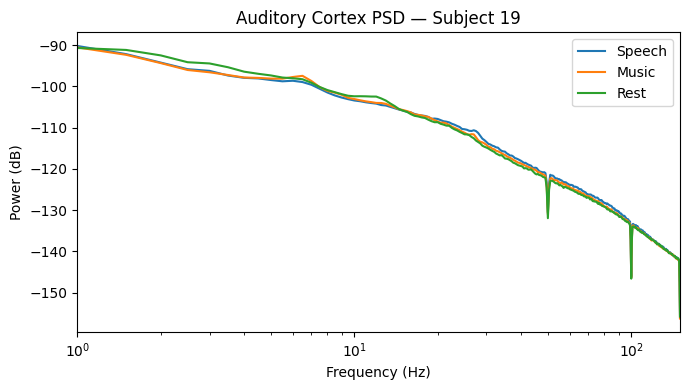

In [3]:
import matplotlib.pyplot as plt

example_idx = 6

freqs_ind  = group_freqs[example_idx]
speech_ind = group_speech[example_idx]
music_ind  = group_music[example_idx]
rest_ind   = group_rest[example_idx]

plt.figure(figsize=(7, 4))

plt.semilogx(freqs_ind, speech_ind, label="Speech")
plt.semilogx(freqs_ind, music_ind,  label="Music")
plt.semilogx(freqs_ind, rest_ind,   label="Rest")

plt.xlim(1, 150)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")
plt.title(f"Auditory Cortex PSD — Subject {processed_subjects[example_idx]}")
plt.legend()
plt.tight_layout()
plt.show()


Final shapes:
Speech: (9, 299)
Music : (9, 299)
Rest  : (9, 299)


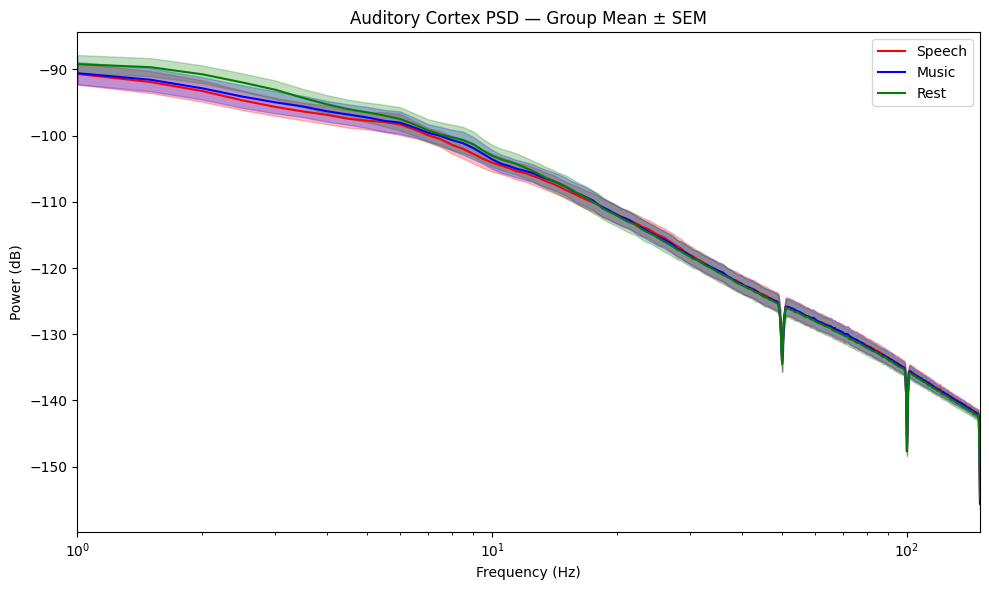

In [4]:
min_len = min(len(f) for f in group_freqs)
freqs_axis = group_freqs[0][:min_len]

group_speech = np.array([psd[:min_len] for psd in group_speech])
group_music  = np.array([psd[:min_len] for psd in group_music])
group_rest   = np.array([psd[:min_len] for psd in group_rest])

print("Final shapes:")
print("Speech:", group_speech.shape)
print("Music :", group_music.shape)
print("Rest  :", group_rest.shape)

n_subj = group_speech.shape[0]

mean_speech = group_speech.mean(axis=0)
mean_music  = group_music.mean(axis=0)
mean_rest   = group_rest.mean(axis=0)

sem_speech = group_speech.std(axis=0, ddof=1) / np.sqrt(n_subj)
sem_music  = group_music.std(axis=0, ddof=1)  / np.sqrt(n_subj)
sem_rest   = group_rest.std(axis=0, ddof=1)   / np.sqrt(n_subj)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.semilogx(freqs_axis, mean_speech, label='Speech', color='red')
plt.fill_between(freqs_axis,
                 mean_speech - sem_speech,
                 mean_speech + sem_speech,
                 color='red', alpha=0.25)

plt.semilogx(freqs_axis, mean_music, label='Music', color='blue')
plt.fill_between(freqs_axis,
                 mean_music - sem_music,
                 mean_music + sem_music,
                 color='blue', alpha=0.25)

plt.semilogx(freqs_axis, mean_rest, label='Rest', color='green')
plt.fill_between(freqs_axis,
                 mean_rest - sem_rest,
                 mean_rest + sem_rest,
                 color='green', alpha=0.25)

plt.xlim(1, 150)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (dB)')
plt.title('Auditory Cortex PSD — Group Mean ± SEM')
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
bands = {
    "gamma": (30, 70),
    "high_gamma": (70, 150)
}


In [6]:
band_power = {
    "speech": {},
    "music": {},
    "rest": {}
}

for band, (fmin, fmax) in bands.items():
    mask = (freqs_axis >= fmin) & (freqs_axis <= fmax)

    band_power["speech"][band] = group_speech[:, mask].mean(axis=1)
    band_power["music"][band]  = group_music[:,  mask].mean(axis=1)
    band_power["rest"][band]   = group_rest[:,   mask].mean(axis=1)


C:\Users\USER\AppData\Local\Temp\ipykernel_41788\2432746365.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


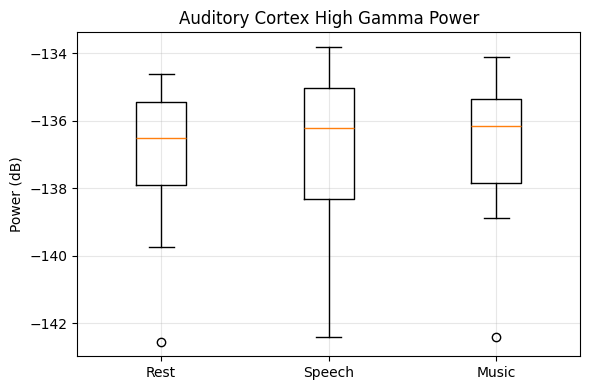

In [7]:
import matplotlib.pyplot as plt

band = "high_gamma"  

plt.figure(figsize=(6, 4))
plt.boxplot(
    [
        band_power["rest"][band],
        band_power["speech"][band],
        band_power["music"][band],
    ],
    labels=["Rest", "Speech", "Music"]
)

plt.ylabel("Power (dB)")
plt.title(f"Auditory Cortex {band.replace('_', ' ').title()} Power")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_41788\3521044398.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([speech_rel, music_rel], labels=["Speech − Rest", "Music − Rest"])


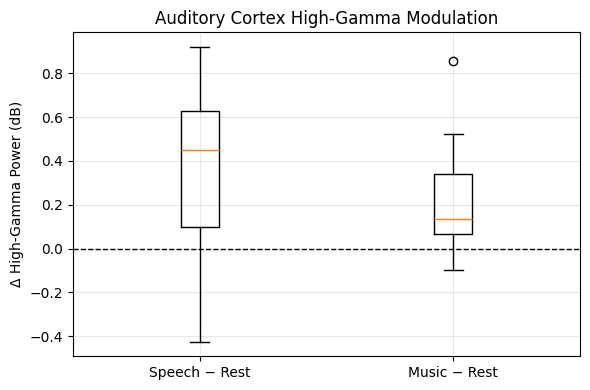

In [8]:
speech_rel = band_power["speech"]["high_gamma"] - band_power["rest"]["high_gamma"]
music_rel  = band_power["music"]["high_gamma"]  - band_power["rest"]["high_gamma"]

plt.figure(figsize=(6, 4))
plt.boxplot([speech_rel, music_rel], labels=["Speech − Rest", "Music − Rest"])
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.ylabel("Δ High-Gamma Power (dB)")
plt.title("Auditory Cortex High-Gamma Modulation")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
from scipy.stats import ttest_1samp, wilcoxon
import numpy as np

print("High-Gamma Modulation Statistics\n")

t_s, p_s = ttest_1samp(speech_rel, 0)
w_s, p_ws = wilcoxon(speech_rel)

print("Speech − Rest")
print(f"  t-test     : t = {t_s:.3f}, p = {p_s:.4e}")
print(f"  Wilcoxon   : W = {w_s:.3f}, p = {p_ws:.4e}")

t_m, p_m = ttest_1samp(music_rel, 0)
w_m, p_wm = wilcoxon(music_rel)

print("\nMusic − Rest")
print(f"  t-test     : t = {t_m:.3f}, p = {p_m:.4e}")
print(f"  Wilcoxon   : W = {w_m:.3f}, p = {p_wm:.4e}")


High-Gamma Modulation Statistics

Speech − Rest
  t-test     : t = 2.130, p = 6.5776e-02
  Wilcoxon   : W = 7.000, p = 7.4219e-02

Music − Rest
  t-test     : t = 2.419, p = 4.1916e-02
  Wilcoxon   : W = 4.000, p = 2.7344e-02


In [10]:
def cohens_d_1samp(x):
    return np.mean(x) / np.std(x, ddof=1)

print("\nEffect Sizes (Cohen's d)")

d_s = cohens_d_1samp(speech_rel)
d_m = cohens_d_1samp(music_rel)

print(f"Speech − Rest : d = {d_s:.3f}")
print(f"Music  − Rest : d = {d_m:.3f}")



Effect Sizes (Cohen's d)
Speech − Rest : d = 0.710
Music  − Rest : d = 0.806


In [11]:
t_sm, p_sm = ttest_1samp(speech_rel - music_rel, 0)
w_sm, p_wsm = wilcoxon(speech_rel - music_rel)

print("\nSpeech vs Music (relative gamma)")
print(f"  t-test   : t = {t_sm:.3f}, p = {p_sm:.4e}")
print(f"  Wilcoxon : W = {w_sm:.3f}, p = {p_wsm:.4e}")



Speech vs Music (relative gamma)
  t-test   : t = 0.791, p = 4.5196e-01
  Wilcoxon : W = 16.000, p = 4.9609e-01


In [12]:
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta":  (13, 30),
    "gamma": (30, 70),
    "high_gamma": (70, 150)
}


In [13]:
band_power = {
    "speech": {},
    "music": {},
    "rest": {}
}

for band, (fmin, fmax) in bands.items():
    mask = (freqs_axis >= fmin) & (freqs_axis <= fmax)

    band_power["speech"][band] = group_speech[:, mask].mean(axis=1)
    band_power["music"][band]  = group_music[:,  mask].mean(axis=1)
    band_power["rest"][band]   = group_rest[:,   mask].mean(axis=1)


C:\Users\USER\AppData\Local\Temp\ipykernel_41788\774048515.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([speech_rel, music_rel],


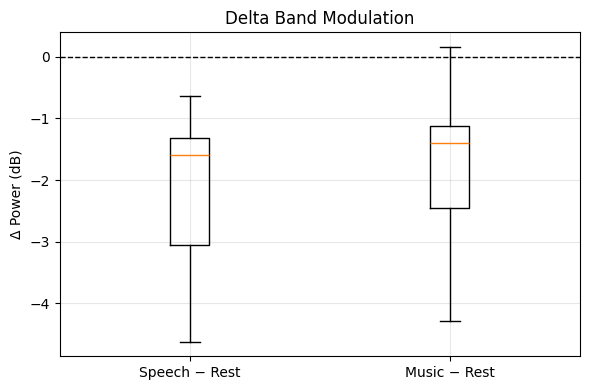

C:\Users\USER\AppData\Local\Temp\ipykernel_41788\774048515.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([speech_rel, music_rel],


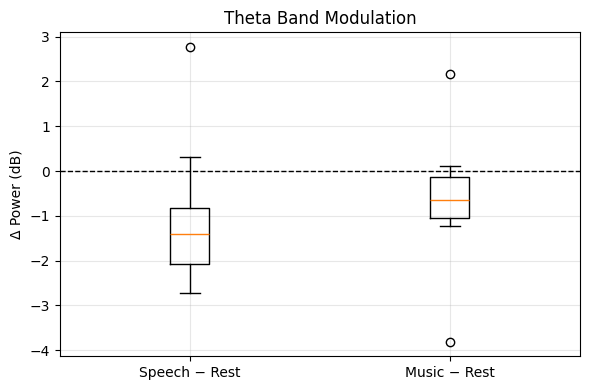

C:\Users\USER\AppData\Local\Temp\ipykernel_41788\774048515.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([speech_rel, music_rel],


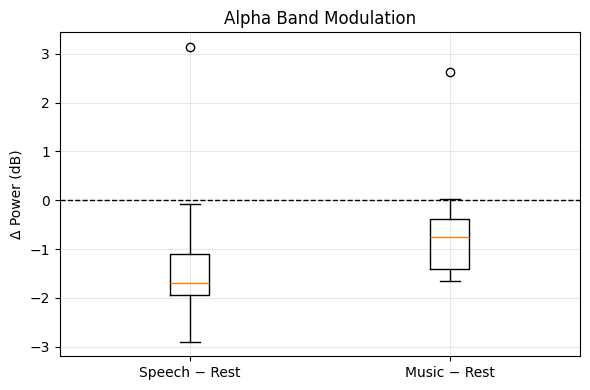

C:\Users\USER\AppData\Local\Temp\ipykernel_41788\774048515.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([speech_rel, music_rel],


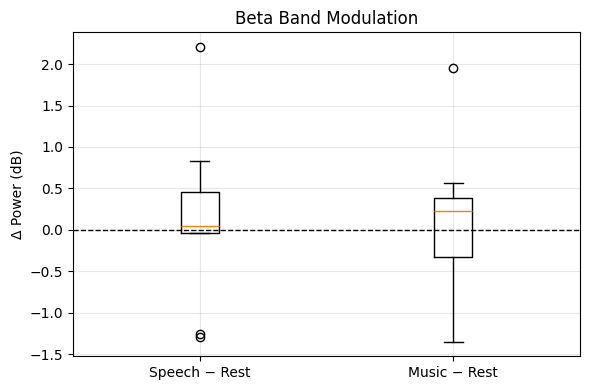

C:\Users\USER\AppData\Local\Temp\ipykernel_41788\774048515.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([speech_rel, music_rel],


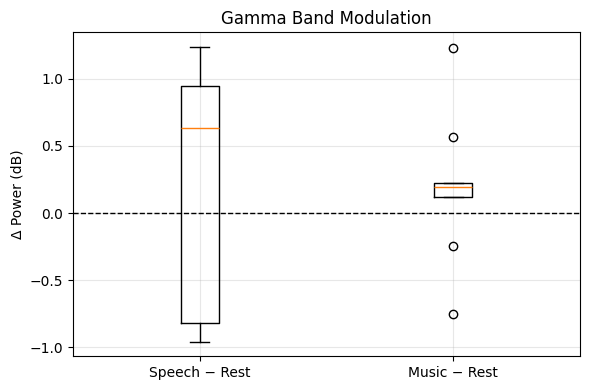

C:\Users\USER\AppData\Local\Temp\ipykernel_41788\774048515.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([speech_rel, music_rel],


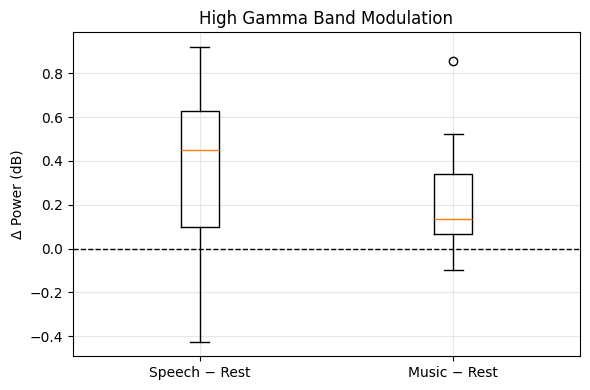

In [14]:
import matplotlib.pyplot as plt

for band in bands.keys():
    speech_rel = band_power["speech"][band] - band_power["rest"][band]
    music_rel  = band_power["music"][band]  - band_power["rest"][band]

    plt.figure(figsize=(6, 4))
    plt.boxplot([speech_rel, music_rel],
                labels=["Speech − Rest", "Music − Rest"])
    plt.axhline(0, color="black", linestyle="--", linewidth=1)

    plt.ylabel("Δ Power (dB)")
    plt.title(f"{band.replace('_', ' ').title()} Band Modulation")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [15]:
from scipy.stats import ttest_1samp, wilcoxon
import numpy as np

def cohens_t(x):
    return np.mean(x) / np.std(x, ddof=1)

for band in bands.keys():
    print(f"\n=== {band.upper()} BAND ===")

    speech_rel = band_power["speech"][band] - band_power["rest"][band]
    music_rel  = band_power["music"][band]  - band_power["rest"][band]

    # Speech vs Rest
    t_s, p_s = ttest_1samp(speech_rel, 0)
    w_s, p_ws = wilcoxon(speech_rel)
    d_s = cohens_t(speech_rel)

    # Music vs Rest
    t_m, p_m = ttest_1samp(music_rel, 0)
    w_m, p_wm = wilcoxon(music_rel)
    d_m = cohens_t(music_rel)

    print("Speech − Rest:")
    print(f"  t-test: p={p_s:.3e}, Wilcoxon: p={p_ws:.3e}, d={d_s:.2f}")

    print("Music − Rest:")
    print(f"  t-test: p={p_m:.3e}, Wilcoxon: p={p_wm:.3e}, d={d_m:.2f}")



=== DELTA BAND ===
Speech − Rest:
  t-test: p=1.110e-03, Wilcoxon: p=3.906e-03, d=-1.65
Music − Rest:
  t-test: p=4.614e-03, Wilcoxon: p=7.812e-03, d=-1.30

=== THETA BAND ===
Speech − Rest:
  t-test: p=9.869e-02, Wilcoxon: p=1.641e-01, d=-0.62
Music − Rest:
  t-test: p=2.751e-01, Wilcoxon: p=1.289e-01, d=-0.39

=== ALPHA BAND ===
Speech − Rest:
  t-test: p=9.812e-02, Wilcoxon: p=1.289e-01, d=-0.62
Music − Rest:
  t-test: p=2.455e-01, Wilcoxon: p=1.641e-01, d=-0.42

=== BETA BAND ===
Speech − Rest:
  t-test: p=7.183e-01, Wilcoxon: p=6.523e-01, d=0.12
Music − Rest:
  t-test: p=6.810e-01, Wilcoxon: p=6.523e-01, d=0.14

=== GAMMA BAND ===
Speech − Rest:
  t-test: p=4.911e-01, Wilcoxon: p=5.703e-01, d=0.24
Music − Rest:
  t-test: p=3.113e-01, Wilcoxon: p=3.594e-01, d=0.36

=== HIGH_GAMMA BAND ===
Speech − Rest:
  t-test: p=6.578e-02, Wilcoxon: p=7.422e-02, d=0.71
Music − Rest:
  t-test: p=4.192e-02, Wilcoxon: p=2.734e-02, d=0.81


In [16]:
import pandas as pd

rows = []

for band in bands.keys():
    speech_rel = band_power["speech"][band] - band_power["rest"][band]
    music_rel  = band_power["music"][band]  - band_power["rest"][band]

    rows.append({
        "Band": band,
        "Speech − Rest (mean)": np.mean(speech_rel),
        "Music − Rest (mean)": np.mean(music_rel),
        "Speech d": cohens_t(speech_rel),
        "Music d": cohens_t(music_rel)
    })

df_stats = pd.DataFrame(rows)
df_stats


,Band,Speech − Rest (mean),Music − Rest (mean),Speech d,Music d
0,delta,-2.167524,-1.680933,-1.652543,-1.296434
1,theta,-1.050720,-0.607964,-0.622707,-0.390494
2,alpha,-1.116738,-0.558388,-0.623960,-0.417725
3,beta,0.131728,0.131807,0.124578,0.142167
4,gamma,0.220708,0.193486,0.240549,0.360290
5,high_gamma,0.324448,0.237325,0.710056,0.806332
